# Laboratorio 7 — ENEIC: calidad y análisis exploratorio

**Alcance:** ejercicios 1, 2 y 3 recibidos, más los criterios generales del laboratorio.
Las preguntas sobre perfiles de trabajadores y capacidad predictiva requieren las etapas
de clustering y regresión, cuyas instrucciones todavía no se han recibido.

**Población analítica:** registros de personas de 15 años o más, ocupadas, asalariadas
(categorías 1–4), con salario mensual positivo registrado y predictores numéricos válidos.
El objetivo es `P05D01`, salario mensual bruto de la ocupación principal en quetzales;
no se sustituye por YLAB_PUBLI ni se agregan remesas, otras ocupaciones o prestaciones.
No se imputan salarios, no se recortan extremos y no se transforma el objetivo.

**Diseño:** análisis no ponderado. FACTOR se conserva, pero no se usa como predictor ni
como peso. Serviría para expandir observaciones en un análisis poblacional que también
considere el diseño muestral y la rotación longitudinal. Las asociaciones no son causales.

**Organización:** originales intactos en `Data/`, derivados en `Transform_Data/` y este
notebook en `Notebooks/`. Ejecutar de principio a fin con Spark 3.5.x.
Las interpretaciones numéricas se generan desde los resultados de Spark, no desde muestras.

In [1]:
from pathlib import Path
from functools import reduce
import json
import math
import hashlib
import platform
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import pyspark
from IPython.display import display, Markdown
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'Data').is_dir(), 'Montar la carpeta completa del laboratorio y ejecutar desde ella o Notebooks.'
DATA, OUT = ROOT / 'Data', ROOT / 'Transform_Data'
OUT.mkdir(exist_ok=True)
assert pyspark.__version__.startswith('3.5.'), f'Se requiere PySpark 3.5.x, actual: {pyspark.__version__}'
spark = (SparkSession.builder.master('local[2]').appName('L07_ENEIC_EDA')
         .config('spark.sql.shuffle.partitions', '8')
         .config('spark.sql.ansi.enabled', 'false')
         .config('spark.driver.memory', '2g').getOrCreate())
assert spark.version.startswith('3.5.')
spark.sparkContext.setLogLevel('WARN')
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False, 'axes.spines.right': False})

PERIODOS = {'2025T1': (51588, 270), '2025T2': (51167, 270),
            '2025T3': (51583, 270), '2025T4': (49338, 302), '2026T1': (49843, 270)}
ORIGINALES = 'P05D01 P02A03 P05C07A P05C07B P05H01A P03A03A P05C16 DOMINIO OCUPADOS NUM_HOGAR NUM_PERSONA FACTOR ANIO TRIMESTRE'.split()
NUMERICAS = {'P05D01': 'salario_mensual', 'P02A03': 'edad', 'P05C07A': 'antiguedad_anios',
             'P05C07B': 'antiguedad_meses', 'P05H01A': 'horas_semanales'}
CATEGORICAS = {'P03A03A': 'nivel_educativo', 'P05C16': 'categoria_ocupacional', 'DOMINIO': 'dominio'}
CLAVE = ['periodo_archivo', 'NUM_HOGAR', 'NUM_PERSONA']
VARIABLES = ['salario_mensual', 'edad', 'antiguedad', 'horas_semanales']
ETIQUETAS = {'salario_mensual': 'Salario mensual (Q)', 'edad': 'Edad (años)',
             'antiguedad': 'Antigüedad (años)', 'horas_semanales': 'Horas habituales por semana'}
PREDICTORES = ['edad', 'antiguedad', 'horas_semanales', 'nivel_educativo', 'categoria_ocupacional', 'dominio']

def explicar(texto):
    display(Markdown(texto))

def guardar_grafica(nombre):
    plt.tight_layout()
    plt.savefig(OUT / f'{nombre}.png', dpi=160, bbox_inches='tight')
    plt.show()

def tabla(df, nombre):
    # Sólo tablas agregadas o auditorías pequeñas, nunca la base analítica completa.
    assert len(df) <= 10000
    display(df)
    df.to_csv(OUT / f'{nombre}.csv', index=False)

print('Python:', platform.python_version(), '| Spark:', spark.version)

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 23:51:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Python: 3.11.16 | Spark: 3.5.1


## 1. Carga, armonización y calidad de datos

### Diccionarios y códigos
Se leen las etiquetas de valores de cada diccionario, separadas de su listado de variables.
Se homologa `1`, `1.0` y `"1"` como el código `"1"`. Un código no reconocido o ausente
se representa como `DESCONOCIDO`; **0 en educación es ninguno**, no un faltante.

In [2]:
def leer_codigos(path):
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    catalogo = {v: {} for v in CATEGORICAS}
    actual = None
    for row in wb.active.iter_rows(values_only=True):
        variable, valor, etiqueta, medida = (list(row) + [None] * 4)[:4]
        if variable is not None:
            actual = str(variable).strip() if str(variable).strip() in catalogo and medida is None else None
        if actual and valor is not None and etiqueta is not None:
            try:
                numero = float(valor)
                if math.isfinite(numero) and numero.is_integer():
                    catalogo[actual][str(int(numero))] = str(etiqueta).strip()
            except (TypeError, ValueError):
                pass
    wb.close()
    assert all(catalogo.values()), f'No se pudieron leer categorías: {path}'
    assert '0' in catalogo['P03A03A']
    return catalogo

CATALOGOS = {p: leer_codigos(DATA / f'diccionario_{p}.xlsx') for p in PERIODOS}
for periodo, catalogo in CATALOGOS.items():
    print(periodo, {v: sorted(codigos) for v, codigos in catalogo.items()})
for variable in CATEGORICAS:
    assert all(set(c[variable]) == set(CATALOGOS['2025T1'][variable]) for c in CATALOGOS.values())

2025T1 {'P03A03A': ['0', '1', '2', '3', '4', '5', '6', '7'], 'P05C16': ['1', '2', '3', '4', '5', '6', '7', '8', '9'], 'DOMINIO': ['1', '2', '3']}
2025T2 {'P03A03A': ['0', '1', '2', '3', '4', '5', '6', '7'], 'P05C16': ['1', '2', '3', '4', '5', '6', '7', '8', '9'], 'DOMINIO': ['1', '2', '3']}
2025T3 {'P03A03A': ['0', '1', '2', '3', '4', '5', '6', '7'], 'P05C16': ['1', '2', '3', '4', '5', '6', '7', '8', '9'], 'DOMINIO': ['1', '2', '3']}
2025T4 {'P03A03A': ['0', '1', '2', '3', '4', '5', '6', '7'], 'P05C16': ['1', '2', '3', '4', '5', '6', '7', '8', '9'], 'DOMINIO': ['1', '2', '3']}
2026T1 {'P03A03A': ['0', '1', '2', '3', '4', '5', '6', '7'], 'P05C16': ['1', '2', '3', '4', '5', '6', '7', '8', '9'], 'DOMINIO': ['1', '2', '3']}


### Entrada individual de Excel y unión por nombre
Pandas sólo realiza la lectura de cada Excel. Spark recibe un esquema explícito de texto
para conservar los valores originales y realiza las conversiones analíticas posteriores.
Antes de seleccionar columnas se calcula una huella SHA-256 del registro completo, que
permitirá distinguir repeticiones exactas de conflictos incluso en variables no seleccionadas.
Las fuentes originales siguen disponibles para investigar los conflictos.

Se conserva ANIO y TRIMESTRE, y el período calendario se asigna **por archivo**. No se
resta uno a TRIMESTRE: en 2025T2 hay registros con el código 2, además del código 3.

In [3]:
def codigo_normalizado(nombre):
    valor = F.trim(F.col(nombre)).cast('double')
    return F.when(valor.isNotNull() & ~F.isnan(valor) & (F.abs(valor) != float('inf')) &
                  (valor == F.floor(valor)), valor.cast('long').cast('string'))

auditoria_archivos = []
for periodo, esperado in PERIODOS.items():
    archivo = DATA / f'personas_{periodo}.xlsx'
    pdf = pd.read_excel(archivo, dtype=str, engine='openpyxl')
    pdf.columns = [str(x).strip().upper() for x in pdf.columns]
    assert pdf.columns.is_unique, f'Columnas repetidas: {archivo.name}'
    assert not (set(ORIGINALES) - set(pdf.columns)), f'Columnas faltantes: {archivo.name}'
    filas, columnas = pdf.shape
    auditoria_archivos.append((periodo, filas, columnas, esperado[0], esperado[1], (filas, columnas) == esperado))
    assert (filas, columnas) == esperado, f'Revisar versión del archivo {periodo}: {pdf.shape} vs {esperado}'
    pdf = pdf.astype(object).where(pdf.notna(), None)
    esquema = T.StructType([T.StructField(x, T.StringType(), True) for x in pdf.columns])
    df = spark.createDataFrame(pdf.itertuples(index=False, name=None), esquema)
    del pdf
    huella = F.sha2(F.to_json(F.struct(*[F.col(x) for x in sorted(df.columns)]),
                             options={'ignoreNullFields': 'false'}), 256)
    df = df.select(*ORIGINALES, huella.alias('huella_registro_completo'))
    df = (df.withColumn('periodo_archivo', F.lit(periodo))
          .withColumn('anio_archivo', F.lit(int(periodo[:4])))
          .withColumn('trimestre_calendario', F.lit(int(periodo[-1])))
          .withColumn('archivo_origen', F.lit(archivo.name)))
    for original, analitica in NUMERICAS.items():
        df = df.withColumn(analitica, F.trim(F.col(original)).cast('double'))
    for original, analitica in CATEGORICAS.items():
        normal = codigo_normalizado(original)
        df = df.withColumn(analitica, F.when(normal.isin(list(CATALOGOS[periodo][original])), normal)
                           .otherwise('DESCONOCIDO'))
    for identificador in ['NUM_HOGAR', 'NUM_PERSONA']:
        df = df.withColumn(identificador + '_original', F.col(identificador))
        df = df.withColumn(identificador, F.coalesce(codigo_normalizado(identificador), F.trim(F.col(identificador))))
    df = df.withColumn('ocupado', codigo_normalizado('OCUPADOS'))
    df = df.withColumn('antiguedad', F.col('antiguedad_anios') + F.col('antiguedad_meses') / 12)
    df.write.mode('overwrite').parquet(str(OUT / 'convertidos' / periodo))
    print('Convertido:', periodo)

auditoria_archivos = pd.DataFrame(auditoria_archivos, columns=['periodo_archivo', 'filas', 'columnas', 'filas_esperadas', 'columnas_esperadas', 'coincide'])
tabla(auditoria_archivos, 'auditoria_archivos')
# Unión explícita de los CUATRO archivos de 2025 por NOMBRE, no por posición.
datos_2025 = reduce(lambda a, b: a.unionByName(b),
    [spark.read.parquet(str(OUT / 'convertidos' / p)) for p in PERIODOS if p.startswith('2025')])
datos_2026 = spark.read.parquet(str(OUT / 'convertidos' / '2026T1'))
datos = datos_2025.unionByName(datos_2026).cache()
seleccionadas = ORIGINALES + list(NUMERICAS.values()) + list(CATEGORICAS.values()) + ['ocupado', 'antiguedad', 'periodo_archivo', 'anio_archivo', 'trimestre_calendario', 'archivo_origen']
datos_2025.select(*seleccionadas).printSchema()
datos_2025.select(*seleccionadas).show(5, truncate=False, vertical=True)
tabla(datos.groupBy('periodo_archivo', 'TRIMESTRE').count().orderBy('periodo_archivo', 'TRIMESTRE').toPandas(), 'trimestre_original')

26/09/24 23:53:44 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/09/24 23:53:45 WARN TaskSetManager: Stage 0 contains a task of very large size (12886 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

Convertido: 2025T1


26/09/24 23:54:40 WARN TaskSetManager: Stage 1 contains a task of very large size (9742 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

Convertido: 2025T2


26/09/24 23:56:28 WARN TaskSetManager: Stage 2 contains a task of very large size (12967 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

...

26/09/24 23:59:52 WARN TaskSetManager: Stage 4 contains a task of very large size (12467 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

Convertido: 2026T1


,periodo_archivo,filas,columnas,filas_esperadas,columnas_esperadas,coincide
0,2025T1,51588,270,51588,270,True
1,2025T2,51167,270,51167,270,True
2,2025T3,51583,270,51583,270,True
3,2025T4,49338,302,49338,302,True
4,2026T1,49843,270,49843,270,True


root
 |-- P05D01: string (nullable = true)
 |-- P02A03: string (nullable = true)
 |-- P05C07A: string (nullable = true)
 |-- P05C07B: string (nullable = true)
 |-- P05H01A: string (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: string (nullable = true)
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- ocupado: string (nullable = true)
 |-- antiguedad: double (nullable = true)
 

,periodo_archivo,TRIMESTRE,count
0,2025T1,2,51588
1,2025T2,2,175
2,2025T2,3,50992
3,2025T3,4,51583
4,2025T4,5,49338
5,2026T1,6,49843


### Faltantes antes de filtrar
Se considera ausente un nulo, una cadena vacía o un marcador textual de ausencia
(`nan`, `null`, `none`, `na`, `n/a`). No se considera 0 un faltante.
Se reportan los faltantes de **todas las variables originales seleccionadas**, por archivo
y para 2025 acumulado. Un código inválido se diferencia de un dato ausente mediante una
auditoría adicional de `DESCONOCIDO`. Una conversión numérica fallida se excluye en los filtros.

In [4]:
def ausente(nombre):
    x = F.lower(F.trim(F.col(nombre).cast('string')))
    return F.col(nombre).isNull() | x.isin('', 'nan', 'null', 'none', 'na', 'n/a')

def faltantes(df, por_periodo=True):
    expresiones = [F.count('*').alias('total')] + [F.sum(F.when(ausente(v), 1).otherwise(0)).alias(v) for v in ORIGINALES]
    agregado = df.groupBy('periodo_archivo').agg(*expresiones) if por_periodo else df.agg(*expresiones).withColumn('periodo_archivo', F.lit('2025_TOTAL'))
    return (agregado.select('periodo_archivo', 'total', F.explode(F.array(*[
        F.struct(F.lit(v).alias('variable'), F.col(v).alias('faltantes')) for v in ORIGINALES])).alias('dato'))
        .select('periodo_archivo', 'dato.*', 'total')
        .withColumn('porcentaje', 100 * F.col('faltantes') / F.col('total')))

faltantes_tabla = faltantes(datos).unionByName(faltantes(datos_2025, False)).orderBy('periodo_archivo', 'variable').toPandas()
tabla(faltantes_tabla, 'faltantes_antes_filtros')
desconocidos = datos.groupBy('periodo_archivo').agg(*[
    F.sum(F.when(F.col(v) == 'DESCONOCIDO', 1).otherwise(0)).alias(v) for v in CATEGORICAS.values()])
tabla(desconocidos.orderBy('periodo_archivo').toPandas(), 'categorias_desconocidas_antes_filtros')
top = faltantes_tabla.query("periodo_archivo == '2025_TOTAL'").sort_values('porcentaje', ascending=False).iloc[0]
explicar(f"En 2025, **{top.variable}** presenta el mayor porcentaje de ausencias entre las variables seleccionadas: **{top.porcentaje:.2f}%** ({int(top.faltantes):,} de {int(top.total):,} registros). Este conteo describe ausencia, pero no identifica por sí solo su causa. Las preguntas laborales pueden no corresponder a personas fuera de la población ocupada; no debe interpretarse toda ausencia como error de captura.")

,periodo_archivo,variable,faltantes,total,porcentaje
0,2025T1,ANIO,0,51588,0.000000
1,2025T1,DOMINIO,0,51588,0.000000
2,2025T1,FACTOR,0,51588,0.000000
3,2025T1,NUM_HOGAR,0,51588,0.000000
4,2025T1,NUM_PERSONA,0,51588,0.000000
...,...,...,...,...,...
79,2026T1,P05C07B,28109,49843,56.395081
80,2026T1,P05C16,28109,49843,56.395081
81,2026T1,P05D01,36585,49843,73.400477
82,2026T1,P05H01A,28109,49843,56.395081


,periodo_archivo,nivel_educativo,categoria_ocupacional,dominio
0,2025T1,6928,29315,0
1,2025T2,6678,28824,0
2,2025T3,6548,29210,0
3,2025T4,6190,28105,0
4,2026T1,6011,28109,0


En 2025, **P05D01** presenta el mayor porcentaje de ausencias entre las variables seleccionadas: **73.97%** (150,651 de 203,676 registros). Este conteo describe ausencia, pero no identifica por sí solo su causa. Las preguntas laborales pueden no corresponder a personas fuera de la población ocupada; no debe interpretarse toda ausencia como error de captura.

### Unicidad y estudio de duplicados antes de filtrar
La clave incluye el período. Se cuenta cada grupo repetido y se distingue:
**repetición exacta** (una sola huella de todas las columnas originales) frente a
**conflicto** (más de una huella). No se elimina ningún registro automáticamente.
También se verifican claves incompletas; una clave ausente no prueba identidad personal.

In [5]:
grupos_clave = datos.groupBy(*CLAVE).agg(F.count('*').alias('registros'),
    F.countDistinct('huella_registro_completo').alias('versiones_completas'))
duplicados = (grupos_clave.filter(F.col('registros') > 1)
    .withColumn('tipo', F.when(F.col('versiones_completas') == 1, 'repeticion_exacta').otherwise('conflicto')))
duplicados.write.mode('overwrite').parquet(str(OUT / 'claves_duplicadas'))
resumen_dup = duplicados.groupBy('periodo_archivo', 'tipo').agg(
    F.count('*').alias('claves_repetidas'), F.sum('registros').alias('registros_involucrados'))
tabla(resumen_dup.orderBy('periodo_archivo', 'tipo').toPandas(), 'resumen_duplicados')
claves_incompletas = datos.filter(ausente('NUM_HOGAR') | ausente('NUM_PERSONA')).count()
n_dup = duplicados.count()
explicar(f"Se encontraron **{n_dup:,} claves repetidas** y **{claves_incompletas:,} registros con clave incompleta** antes de filtrar. " +
         ('La combinación período, hogar y persona es única en los cinco archivos.' if n_dup == 0 and claves_incompletas == 0 else
          'No se aplica dropDuplicates: se conservan las observaciones y se exporta la auditoría para investigar.'))
if n_dup:
    # Unión null-safe para que las claves incompletas no desaparezcan de la investigación.
    d, k = datos.alias('d'), duplicados.alias('k')
    condicion = reduce(lambda a,b: a & b, [F.col('d.' + v).eqNullSafe(F.col('k.' + v)) for v in CLAVE])
    detalle = d.join(k, condicion, 'inner').select('d.*', 'k.tipo')
    detalle.write.mode('overwrite').parquet(str(OUT / 'detalle_duplicados'))
    diferencias = detalle.groupBy(*CLAVE, 'tipo').agg(*[
        F.countDistinct(F.to_json(F.struct(F.col(v)), options={'ignoreNullFields':'false'})).alias(v + '_versiones')
        for v in ORIGINALES if v not in CLAVE])
    diferencias.write.mode('overwrite').parquet(str(OUT / 'diferencias_duplicados'))
    diferencias.show(30, truncate=False)
    explicar('La tabla muestra cuántos valores distintos tiene cada variable seleccionada dentro de cada clave repetida. Un conflicto de huellas sin cambios en estas variables implica diferencias en columnas originales no seleccionadas, que deben consultarse en el Excel fuente. No se asume cuál registro es correcto.')

,periodo_archivo,tipo,claves_repetidas,registros_involucrados


Se encontraron **0 claves repetidas** y **0 registros con clave incompleta** antes de filtrar. La combinación período, hogar y persona es única en los cinco archivos.

### Filtros secuenciales, con orden fijo
Cada registro se asigna al primer criterio que incumple. Por ello las exclusiones de los
pasos no se solapan. Se incluyen pasos con cero exclusiones y se reconcilian los totales.
Se comprueba finitud, no negatividad de años, meses enteros 0–11, antigüedad ≤ edad y
horas > 0 y ≤ 168. No se imputa el salario ni se descartan extremos por percentiles.

In [6]:
def finito(nombre):
    x = F.col(nombre)
    return x.isNotNull() & ~F.isnan(x) & (F.abs(x) != float('inf'))

reglas = [
    ('Edad finita y al menos 15', finito('edad') & (F.col('edad') >= 15)),
    ('Ocupado = 1', F.col('ocupado') == '1'),
    ('Asalariado: categorías 1–4', F.col('categoria_ocupacional').isin('1','2','3','4')),
    ('Salario finito y positivo', finito('salario_mensual') & (F.col('salario_mensual') > 0)),
    ('Años de antigüedad finitos y no negativos', finito('antiguedad_anios') & (F.col('antiguedad_anios') >= 0)),
    ('Meses enteros de 0 a 11', finito('antiguedad_meses') & F.col('antiguedad_meses').between(0,11) &
     (F.col('antiguedad_meses') == F.floor('antiguedad_meses'))),
    ('Antigüedad finita y no mayor a edad', finito('antiguedad') & (F.col('antiguedad') <= F.col('edad'))),
    ('Horas finitas, mayores a 0 y hasta 168', finito('horas_semanales') & (F.col('horas_semanales') > 0) & (F.col('horas_semanales') <= 168)),
]
motivo = F.lit(0)
for paso, (_, condicion) in reversed(list(enumerate(reglas, start=1))):
    motivo = F.when(~F.coalesce(condicion, F.lit(False)), F.lit(paso)).otherwise(motivo)
auditados = datos.withColumn('paso_exclusion', motivo).cache()
cuentas = auditados.groupBy('periodo_archivo', 'paso_exclusion').count().collect()
mapa = {(r.periodo_archivo, r.paso_exclusion): r['count'] for r in cuentas}
filas_auditoria = []
for periodo, (inicial, _) in PERIODOS.items():
    restante = inicial
    for paso, (nombre, _) in enumerate(reglas, start=1):
        excluidos = mapa.get((periodo, paso), 0)
        filas_auditoria.append((periodo, paso, nombre, restante, excluidos, restante - excluidos))
        restante -= excluidos
    assert restante == mapa.get((periodo, 0), 0)
auditoria_filtros = pd.DataFrame(filas_auditoria, columns=['periodo_archivo','paso','criterio','antes_del_paso','excluidos','despues_del_paso'])
tabla(auditoria_filtros, 'auditoria_filtros')
conteos = auditoria_archivos[['periodo_archivo','filas']].rename(columns={'filas':'antes'}).copy()
conteos['despues'] = conteos.periodo_archivo.map(lambda p: mapa.get((p,0),0))
conteos['excluidos'] = conteos.antes - conteos.despues
conteos['porcentaje_conservado'] = 100 * conteos.despues / conteos.antes
tabla(conteos, 'registros_antes_despues')
limpios = auditados.filter(F.col('paso_exclusion') == 0).drop('paso_exclusion')
for anio in [2025, 2026]:
    limpios.filter(F.col('anio_archivo') == anio).write.mode('overwrite').parquet(str(OUT / f'personas_preparadas_{anio}'))
datos.unpersist()
auditados.unpersist()
base_2025 = spark.read.parquet(str(OUT / 'personas_preparadas_2025')).cache()
base_2026 = spark.read.parquet(str(OUT / 'personas_preparadas_2026'))
assert base_2025.count() == int(conteos[conteos.periodo_archivo.str.startswith('2025')].despues.sum())
assert base_2026.count() == mapa.get(('2026T1',0),0)
dup_limpios = base_2025.unionByName(base_2026).groupBy(*CLAVE).count().filter(F.col('count') > 1).count()
explicar(f"Después de los filtros hay **{dup_limpios:,} claves repetidas**. Los conjuntos preparados de 2025 y 2026 quedaron guardados por separado en Parquet.")
principales = auditoria_filtros[auditoria_filtros.periodo_archivo.str.startswith('2025')].groupby('criterio').excluidos.sum().sort_values(ascending=False)
total_antes = int(conteos[conteos.periodo_archivo.str.startswith('2025')].antes.sum())
total_despues = base_2025.count()
explicar(f"En 2025 se conservan **{total_despues:,} de {total_antes:,} registros ({100*total_despues/total_antes:.2f}%)**. El paso con más exclusiones es **{principales.index[0]}**, con **{int(principales.iloc[0]):,}**. Estos conteos dependen del orden: una observación que incumple varios criterios sólo se contabiliza en el primero. Las exclusiones de edad, ocupación y categoría delimitan la población de interés y no son automáticamente errores de calidad.")

,periodo_archivo,paso,criterio,antes_del_paso,excluidos,despues_del_paso
0,2025T1,1,Edad finita y al menos 15,51588,16253,35335
1,2025T1,2,Ocupado = 1,35335,13062,22273
2,2025T1,3,Asalariado: categorías 1–4,22273,8854,13419
3,2025T1,4,Salario finito y positivo,13419,0,13419
4,2025T1,5,Años de antigüedad finitos y no negativos,13419,0,13419
5,2025T1,6,Meses enteros de 0 a 11,13419,0,13419
6,2025T1,7,Antigüedad finita y no mayor a edad,13419,0,13419
7,2025T1,8,"Horas finitas, mayores a 0 y hasta 168",13419,0,13419
8,2025T2,1,Edad finita y al menos 15,51167,15882,35285
9,2025T2,2,Ocupado = 1,35285,12942,22343


,periodo_archivo,antes,despues,excluidos,porcentaje_conservado
0,2025T1,51588,13419,38169,26.011863
1,2025T2,51167,13492,37675,26.368558
2,2025T3,51583,13450,38133,26.074482
3,2025T4,49338,12664,36674,25.667842
4,2026T1,49843,13258,36585,26.599523


Después de los filtros hay **0 claves repetidas**. Los conjuntos preparados de 2025 y 2026 quedaron guardados por separado en Parquet.

En 2025 se conservan **53,025 de 203,676 registros (26.03%)**. El paso con más exclusiones es **Edad finita y al menos 15**, con **62,886**. Estos conteos dependen del orden: una observación que incumple varios criterios sólo se contabiliza en el primero. Las exclusiones de edad, ocupación y categoría delimitan la población de interés y no son automáticamente errores de calidad.

### Respuestas del ejercicio 1

**¿Por qué IV de 2025 no puede apilarse por posición?** Tiene 302 columnas, mientras
los otros tres archivos tienen 270. Una unión por posición requiere igual cantidad y
orden compatible, y puede asociar valores a variables equivocadas. Se seleccionan las
variables requeridas, se homologan tipos y se usa `unionByName` explícitamente en 2025.

**¿Ausencia porque no corresponde o respuesta no registrada?** La primera es estructural:
por ejemplo, el salario de un empleo asalariado no corresponde a alguien sin ese empleo.
La segunda es una no respuesta en una pregunta que sí debía responderse. Se distinguen
mediante el cuestionario, los saltos y las condiciones de elegibilidad, no sólo por ver un
nulo. No se reemplazan automáticamente por cero ni se imputa el salario.

**¿Por qué no eliminar una persona observada en dos períodos?** Son observaciones
distintas de una trayectoria longitudinal; pueden cambiar salario, edad o empleo. El
período pertenece a la clave de auditoría. La rotación permite observaciones repetidas,
por lo que las filas acumuladas no equivalen a personas diferentes. No se asume que los
identificadores disponibles sean una clave longitudinal estable sin documentación adicional.

**¿Por qué los registros filtrados no representan a todos los trabajadores del país?**
Proceden de una muestra, se restringen a asalariados elegibles con salario positivo
registrado y pasan condiciones de calidad; excluyen, entre otros, trabajadores por cuenta
propia. Además, se apilan períodos y se trabaja sin ponderaciones. Los resultados describen
registros analizados, no totales poblacionales ni estimaciones oficiales de Guatemala.

## 2. Estadística descriptiva y exploración — población analítica de 2025

Se calculan estadísticas sobre **todos** los registros elegibles de 2025 mediante Spark.
La desviación estándar es muestral. Los cuantiles usan `percentile` exacto con interpolación,
incluida la mediana. Sólo se trasladan a pandas tablas agregadas para presentar y graficar.
El conjunto 2026 no se utiliza para explorar salarios ni tomar decisiones de modelado.

In [7]:
resumenes = []
for variable in VARIABLES:
    fila = base_2025.agg(F.count(variable).alias('n'), F.mean(variable).alias('media'),
        F.stddev_samp(variable).alias('desviacion_estandar'), F.min(variable).alias('minimo'),
        F.max(variable).alias('maximo'),
        F.expr(f'percentile({variable}, array(0.25, 0.5, 0.75, 0.95))').alias('p')).first()
    resumenes.append((variable, fila.n, fila.media, fila.p[1], fila.desviacion_estandar,
                      fila.minimo, fila.maximo, fila.p[0], fila.p[2], fila.p[3]))
descriptivos = pd.DataFrame(resumenes, columns=['variable','n','media','mediana','desviacion_estandar','minimo','maximo','p25','p75','p95'])
tabla(descriptivos, 'estadistica_descriptiva_2025')
sal = descriptivos.set_index('variable').loc['salario_mensual']
explicar(f"El salario mensual de los **{int(sal.n):,} registros** tiene media **Q{sal.media:,.2f}** y mediana **Q{sal.mediana:,.2f}**: una diferencia de **Q{sal.media-sal.mediana:,.2f}**. El 50% central se sitúa entre **Q{sal.p25:,.2f} y Q{sal.p75:,.2f}**, y el percentil 95 es **Q{sal.p95:,.2f}**. El máximo (**Q{sal.maximo:,.2f}**) se conserva; los salarios extremos pueden influir en la media, la desviación estándar, las correlaciones y los futuros errores de regresión.")
for variable in ['edad','antiguedad','horas_semanales']:
    r = descriptivos.set_index('variable').loc[variable]
    explicar(f"**{ETIQUETAS[variable]}:** mediana {r.mediana:,.2f}, media {r.media:,.2f}; el 50% central abarca {r.p25:,.2f}–{r.p75:,.2f}. El rango completo es {r.minimo:,.2f}–{r.maximo:,.2f} y la desviación estándar {r.desviacion_estandar:,.2f}.")

,variable,n,media,mediana,desviacion_estandar,minimo,maximo,p25,p75,p95
0,salario_mensual,53025,3421.684206,3000.0,2902.108964,1.0,99000.0,1800.0,4000.0,8000.0
1,edad,53025,35.187647,33.0,13.520902,15.0,89.0,24.0,44.0,61.0
2,antiguedad,53025,5.558828,2.0,7.831017,0.0,70.0,0.5,7.0,22.0
3,horas_semanales,53025,46.307402,45.0,18.630407,1.0,126.0,40.0,55.0,80.0


El salario mensual de los **53,025 registros** tiene media **Q3,421.68** y mediana **Q3,000.00**: una diferencia de **Q421.68**. El 50% central se sitúa entre **Q1,800.00 y Q4,000.00**, y el percentil 95 es **Q8,000.00**. El máximo (**Q99,000.00**) se conserva; los salarios extremos pueden influir en la media, la desviación estándar, las correlaciones y los futuros errores de regresión.

**Edad (años):** mediana 33.00, media 35.19; el 50% central abarca 24.00–44.00. El rango completo es 15.00–89.00 y la desviación estándar 13.52.

**Antigüedad (años):** mediana 2.00, media 5.56; el 50% central abarca 0.50–7.00. El rango completo es 0.00–70.00 y la desviación estándar 7.83.

**Horas habituales por semana:** mediana 45.00, media 46.31; el 50% central abarca 40.00–55.00. El rango completo es 1.00–126.00 y la desviación estándar 18.63.

### Distribución de categorías y salario mediano
Las barras representan conteos no ponderados de registros. Los gráficos de salario por
grupo muestran medianas exactas en quetzales. Las etiquetas se obtienen del diccionario.
Las diferencias son descriptivas: no aíslan el efecto de educación, ocupación u otras variables.

,nivel_educativo,n,salario_mediano,porcentaje,etiqueta
0,0,3995,1500.0,7.534182,NINGUNO
1,1,459,2160.0,0.865629,PREPRIMARIA
2,2,15822,2200.0,29.838755,PRIMARIA
3,3,8249,2800.0,15.556813,BÁSICO
4,4,16851,3600.0,31.779349,DIVERSIFICADO
5,5,6818,5000.0,12.858086,SUPERIOR
6,6,771,10000.0,1.454031,MAESTRÍA
7,7,60,12000.0,0.113154,DOCTORADO


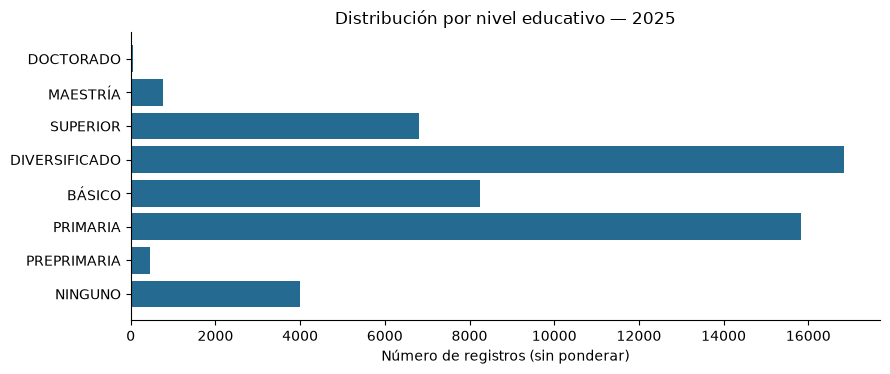

En **nivel educativo**, el grupo con más registros es **DIVERSIFICADO**, con **16,851 (31.78%)**. Estas proporciones corresponden al conjunto filtrado, no a la población nacional.

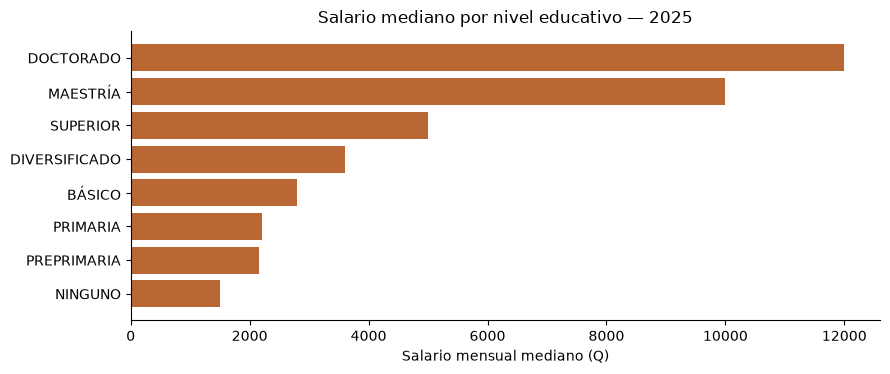

La mediana más alta corresponde a **DOCTORADO: Q12,000.00** (n=60); la más baja, a **NINGUNO: Q1,500.00** (n=3,995). La diferencia es **Q10,500.00**. El tamaño de cada grupo permite contextualizar la comparación; no se ha ajustado por edad, antigüedad, horas u otras condiciones.

,categoria_ocupacional,n,salario_mediano,porcentaje,etiqueta
0,1,6575,5000.0,12.399811,Empleado de gobierno?
1,2,28702,3567.5,54.129184,Empleado de empresa privada?
2,3,13842,1800.0,26.104668,Empleado jornalero o peón?
3,4,3906,1000.0,7.366337,Del servicio doméstico?


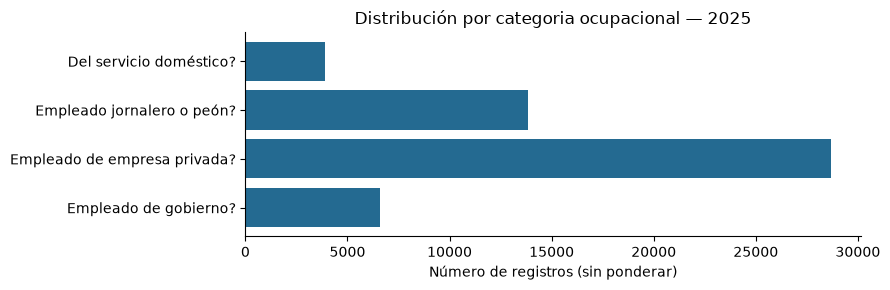

En **categoria ocupacional**, el grupo con más registros es **Empleado de empresa privada?**, con **28,702 (54.13%)**. Estas proporciones corresponden al conjunto filtrado, no a la población nacional.

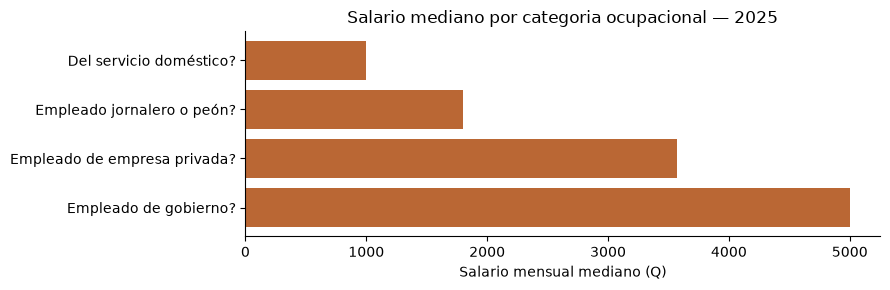

La mediana más alta corresponde a **Empleado de gobierno?: Q5,000.00** (n=6,575); la más baja, a **Del servicio doméstico?: Q1,000.00** (n=3,906). La diferencia es **Q4,000.00**. El tamaño de cada grupo permite contextualizar la comparación; no se ha ajustado por edad, antigüedad, horas u otras condiciones.

,dominio,n,salario_mediano,porcentaje,etiqueta
0,1,22072,3700.0,41.625648,Urbano Metropolitano
1,2,20146,2880.0,37.993399,Resto Urbano
2,3,10807,2000.0,20.380952,Rural Nacional


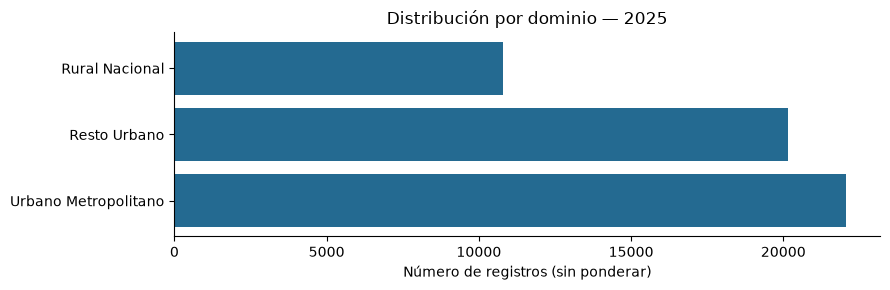

En **dominio**, el grupo con más registros es **Urbano Metropolitano**, con **22,072 (41.63%)**. Estas proporciones corresponden al conjunto filtrado, no a la población nacional.

In [8]:
tablas_grupos = {}
for original, variable in CATEGORICAS.items():
    agregado = (base_2025.groupBy(variable).agg(F.count('*').alias('n'),
        F.expr('percentile(salario_mensual, 0.5)').alias('salario_mediano'))
        .orderBy(variable).toPandas())
    agregado['porcentaje'] = 100 * agregado.n / total_despues
    etiquetas = CATALOGOS['2025T1'][original]
    agregado['etiqueta'] = agregado[variable].map(etiquetas).fillna('DESCONOCIDO')
    tablas_grupos[variable] = agregado
    tabla(agregado, f'distribucion_{variable}_2025')
    plt.figure(figsize=(9, max(3, len(agregado)*0.48)))
    plt.barh(agregado.etiqueta, agregado.n, color='#246a91')
    plt.xlabel('Número de registros (sin ponderar)')
    plt.title(f'Distribución por {variable.replace("_", " ")} — 2025')
    guardar_grafica(f'frecuencia_{variable}')
    principal = agregado.loc[agregado.n.idxmax()]
    explicar(f"En **{variable.replace('_',' ')}**, el grupo con más registros es **{principal.etiqueta}**, con **{int(principal.n):,} ({principal.porcentaje:.2f}%)**. Estas proporciones corresponden al conjunto filtrado, no a la población nacional.")
    if variable in ['nivel_educativo', 'categoria_ocupacional']:
        plt.figure(figsize=(9, max(3, len(agregado)*0.48)))
        plt.barh(agregado.etiqueta, agregado.salario_mediano, color='#ba6734')
        plt.xlabel('Salario mensual mediano (Q)')
        plt.title(f'Salario mediano por {variable.replace("_", " ")} — 2025')
        guardar_grafica(f'mediana_{variable}')
        menor = agregado.loc[agregado.salario_mediano.idxmin()]
        mayor = agregado.loc[agregado.salario_mediano.idxmax()]
        explicar(f"La mediana más alta corresponde a **{mayor.etiqueta}: Q{mayor.salario_mediano:,.2f}** (n={int(mayor.n):,}); la más baja, a **{menor.etiqueta}: Q{menor.salario_mediano:,.2f}** (n={int(menor.n):,}). La diferencia es **Q{mayor.salario_mediano-menor.salario_mediano:,.2f}**. El tamaño de cada grupo permite contextualizar la comparación; no se ha ajustado por edad, antigüedad, horas u otras condiciones.")

### Forma de la distribución del salario
Los histogramas se construyen contando en Spark todos los registros por intervalo. El
primero usa intervalos y eje lineales; el segundo usa intervalos geométricos y eje X
logarítmico, rotulado en quetzales. Ninguno recorta salarios ni transforma el objetivo
guardado para modelar. Las líneas marcan media y mediana del conjunto completo.

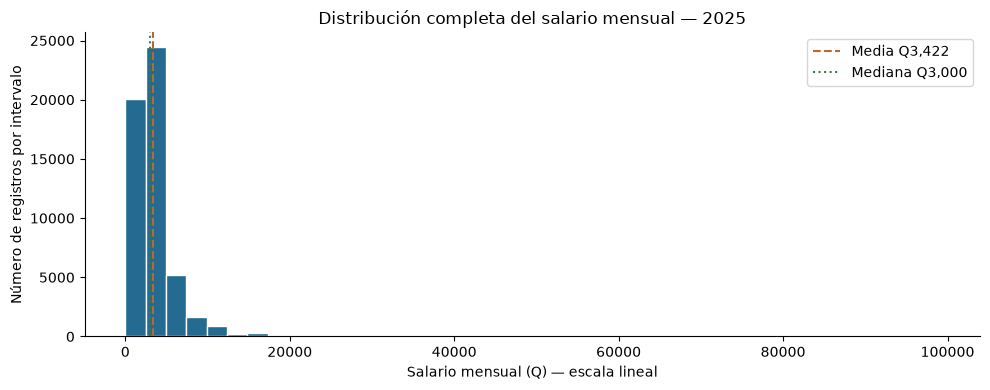

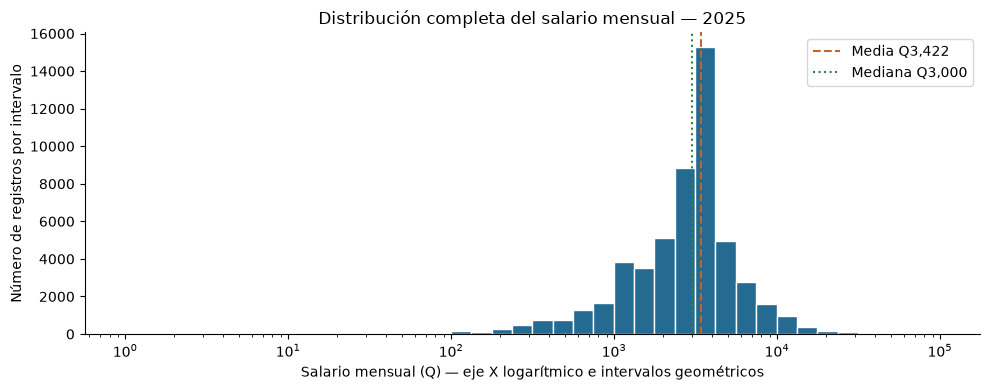

La asimetría calculada sobre todos los registros es **5.997**, hacia la derecha (cola de salarios altos). La comparación de media y mediana y los dos histogramas permiten apreciar la concentración y la cola. El eje logarítmico facilita ver salarios bajos y altos simultáneamente; no representa una transformación del objetivo ni elimina extremos. La media utiliza las magnitudes de todos los valores y es más sensible a extremos que la mediana, que describe el centro por orden.

In [9]:
def histograma_completo(logaritmico=False, bins=40):
    minimo, maximo = float(sal.minimo), float(sal.maximo)
    assert maximo > minimo > 0
    if logaritmico:
        lo, hi = math.log10(minimo), math.log10(maximo)
        valor = F.log10('salario_mensual')
        bordes = np.geomspace(minimo, maximo, bins+1)
    else:
        lo, hi = minimo, maximo
        valor = F.col('salario_mensual')
        bordes = np.linspace(minimo, maximo, bins+1)
    indice = F.greatest(F.lit(0), F.least(F.lit(bins-1), F.floor((valor-lo)/(hi-lo)*bins))).cast('int')
    agregado = base_2025.select(indice.alias('intervalo')).groupBy('intervalo').count().toPandas()
    conteo = agregado.set_index('intervalo')['count'].reindex(range(bins), fill_value=0).to_numpy()
    assert int(conteo.sum()) == total_despues
    plt.figure(figsize=(10,4))
    plt.bar(bordes[:-1], conteo, width=np.diff(bordes), align='edge', color='#246a91', edgecolor='white')
    if logaritmico:
        plt.xscale('log')
    plt.axvline(sal.media, color='#ba6734', linestyle='--', label=f'Media Q{sal.media:,.0f}')
    plt.axvline(sal.mediana, color='#33804a', linestyle=':', label=f'Mediana Q{sal.mediana:,.0f}')
    plt.xlabel('Salario mensual (Q)' + (' — eje X logarítmico e intervalos geométricos' if logaritmico else ' — escala lineal'))
    plt.ylabel('Número de registros por intervalo')
    plt.title('Distribución completa del salario mensual — 2025')
    plt.legend()
    guardar_grafica('salario_histograma_log' if logaritmico else 'salario_histograma_lineal')

histograma_completo(False)
histograma_completo(True)
asimetria = base_2025.agg(F.skewness('salario_mensual')).first()[0]
sentido = 'hacia la derecha (cola de salarios altos)' if asimetria > 0 else 'hacia la izquierda (cola de salarios bajos)' if asimetria < 0 else 'sin asimetría en el tercer momento'
explicar(f"La asimetría calculada sobre todos los registros es **{asimetria:.3f}**, {sentido}. La comparación de media y mediana y los dos histogramas permiten apreciar la concentración y la cola. El eje logarítmico facilita ver salarios bajos y altos simultáneamente; no representa una transformación del objetivo ni elimina extremos. La media utiliza las magnitudes de todos los valores y es más sensible a extremos que la mediana, que describe el centro por orden.")

### Evolución trimestral
Se usa el período asignado por procedencia, no TRIMESTRE original. Los cambios de tamaño
corresponden a observaciones elegibles, y pueden reflejar rotación, composición y filtros.
No prueban cambios en el número nacional de asalariados ni cambios individuales de salario.

,periodo_archivo,n,salario_mediano
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0
2,2025T3,13450,3200.0
3,2025T4,12664,3200.0


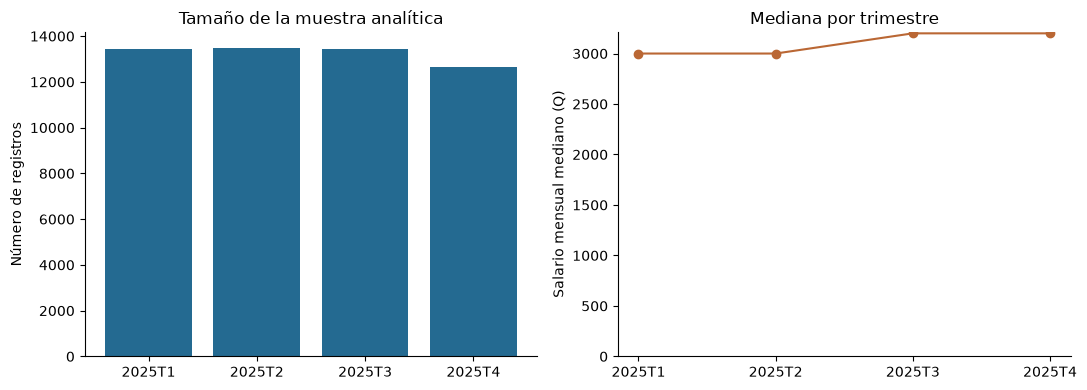

**2025T1:** 13,419 observaciones elegibles y salario mediano **Q3,000.00**.

**2025T2:** 13,492 observaciones elegibles y salario mediano **Q3,000.00**.

**2025T3:** 13,450 observaciones elegibles y salario mediano **Q3,200.00**.

**2025T4:** 12,664 observaciones elegibles y salario mediano **Q3,200.00**.

Entre T1 y T4, el número de registros cambia en **-755 (-5.63%)** y la mediana en **Q+200.00 (+6.67%)**. Son comparaciones entre cortes: la composición y rotación impiden atribuir la diferencia a aumentos salariales de las mismas personas. Los salarios son nominales, sin ajuste por inflación.

In [10]:
trimestres = (base_2025.groupBy('periodo_archivo').agg(F.count('*').alias('n'),
    F.expr('percentile(salario_mensual, 0.5)').alias('salario_mediano'))
    .orderBy('periodo_archivo').toPandas())
tabla(trimestres, 'evolucion_trimestral_2025')
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].bar(trimestres.periodo_archivo, trimestres.n, color='#246a91')
axes[0].set(ylabel='Número de registros', title='Tamaño de la muestra analítica')
axes[1].plot(trimestres.periodo_archivo, trimestres.salario_mediano, marker='o', color='#ba6734')
axes[1].set(ylabel='Salario mensual mediano (Q)', title='Mediana por trimestre')
axes[1].set_ylim(bottom=0)
guardar_grafica('evolucion_trimestral')
for r in trimestres.itertuples():
    explicar(f"**{r.periodo_archivo}:** {r.n:,} observaciones elegibles y salario mediano **Q{r.salario_mediano:,.2f}**.")
primero, ultimo = trimestres.iloc[0], trimestres.iloc[-1]
explicar(f"Entre T1 y T4, el número de registros cambia en **{int(ultimo.n-primero.n):+,} ({100*(ultimo.n/primero.n-1):+.2f}%)** y la mediana en **Q{ultimo.salario_mediano-primero.salario_mediano:+,.2f} ({100*(ultimo.salario_mediano/primero.salario_mediano-1):+.2f}%)**. Son comparaciones entre cortes: la composición y rotación impiden atribuir la diferencia a aumentos salariales de las mismas personas. Los salarios son nominales, sin ajuste por inflación.")

## 3. Relaciones entre variables numéricas

Se interpreta «correlación de Persona» como **correlación de Pearson**, según la API
indicada. `VectorAssembler` y `Correlation.corr(method='pearson')` utilizan todos los
registros elegibles de 2025, con salario original en quetzales. No se pondera por FACTOR.
Una correlación describe asociación lineal; no mide causalidad ni descarta relaciones no lineales.

26/09/25 00:00:34 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/25 00:00:34 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
                                                                                

,Salario mensual (Q),Edad (años),Antigüedad (años),Horas habituales por semana
Salario mensual (Q),1.000000,0.147249,0.179574,0.075665
Edad (años),0.147249,1.000000,0.486713,-0.105378
Antigüedad (años),0.179574,0.486713,1.000000,-0.062256
Horas habituales por semana,0.075665,-0.105378,-0.062256,1.000000


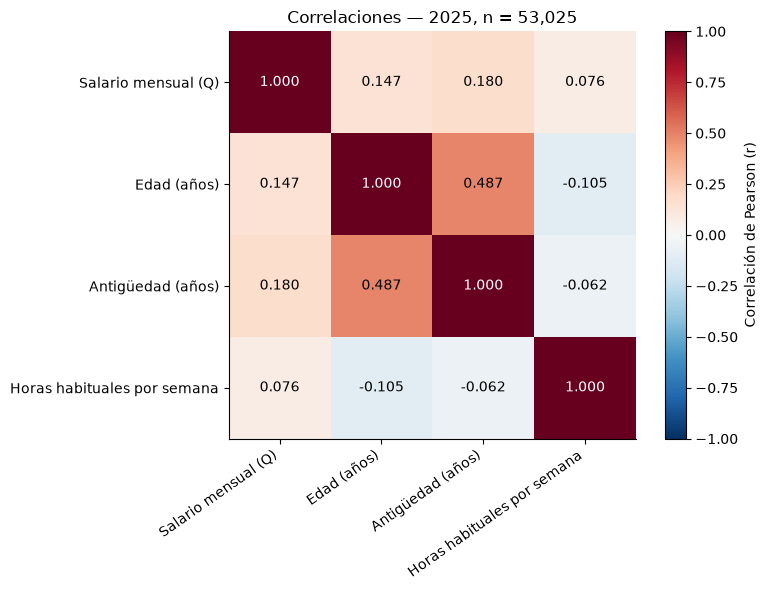

**Asociación lineal con el salario, ordenada por magnitud absoluta:** Antigüedad (años): **r = 0.180**; Edad (años): **r = 0.147**; Horas habituales por semana: **r = 0.076**.

La mayor asociación lineal entre los tres predictores numéricos y salario corresponde a **Antigüedad (años)** (r=0.180). 'Mayor' es una comparación relativa: incluso la correlación más alta puede ser limitada. No se infiere capacidad predictiva suficiente a partir de esta matriz; eso requiere evaluar modelos fuera del entrenamiento.

**Edad y antigüedad:** r = **0.487**, asociación positiva. La antigüedad se acumula con el tiempo y está acotada por la edad en los filtros, por lo que esta relación no implica un efecto causal independiente. Los extremos salariales conservados pueden influir en Pearson. La repetición longitudinal también impide tratar todas las filas como personas independientes para inferencia; aquí se presenta una descripción, sin pruebas de significancia.

In [11]:
vectores = VectorAssembler(inputCols=VARIABLES, outputCol='vector_correlacion', handleInvalid='error').transform(base_2025).select('vector_correlacion')
matriz = Correlation.corr(vectores, 'vector_correlacion', 'pearson').first()[0].toArray()
correlaciones = pd.DataFrame(matriz, index=[ETIQUETAS[v] for v in VARIABLES], columns=[ETIQUETAS[v] for v in VARIABLES])
display(correlaciones)
correlaciones.to_csv(OUT / 'correlacion_pearson_2025.csv', index=True)
fig, ax = plt.subplots(figsize=(8,6))
img = ax.imshow(matriz, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(VARIABLES)), correlaciones.columns, rotation=35, ha='right')
ax.set_yticks(range(len(VARIABLES)), correlaciones.index)
for i in range(len(VARIABLES)):
    for j in range(len(VARIABLES)):
        ax.text(j,i,f'{matriz[i,j]:.3f}',ha='center',va='center',color='white' if abs(matriz[i,j])>.6 else 'black')
fig.colorbar(img, ax=ax, label='Correlación de Pearson (r)')
ax.set_title(f'Correlaciones — 2025, n = {total_despues:,}')
guardar_grafica('mapa_calor_correlaciones')
orden = sorted([(VARIABLES[j],float(matriz[0,j])) for j in range(1,len(VARIABLES))], key=lambda x: abs(x[1]), reverse=True)
explicar('**Asociación lineal con el salario, ordenada por magnitud absoluta:** ' + '; '.join(f'{ETIQUETAS[v]}: **r = {r:.3f}**' for v,r in orden) + '.')
v,r = orden[0]
explicar(f"La mayor asociación lineal entre los tres predictores numéricos y salario corresponde a **{ETIQUETAS[v]}** (r={r:.3f}). 'Mayor' es una comparación relativa: incluso la correlación más alta puede ser limitada. No se infiere capacidad predictiva suficiente a partir de esta matriz; eso requiere evaluar modelos fuera del entrenamiento.")
r_edad_antiguedad = float(matriz[1,2])
explicar(f"**Edad y antigüedad:** r = **{r_edad_antiguedad:.3f}**, asociación {'positiva' if r_edad_antiguedad > 0 else 'negativa' if r_edad_antiguedad < 0 else 'lineal nula'}. La antigüedad se acumula con el tiempo y está acotada por la edad en los filtros, por lo que esta relación no implica un efecto causal independiente. Los extremos salariales conservados pueden influir en Pearson. La repetición longitudinal también impide tratar todas las filas como personas independientes para inferencia; aquí se presenta una descripción, sin pruebas de significancia.")

## Conclusiones y continuidad

Los gráficos y las interpretaciones anteriores responden las preguntas de los ejercicios
1–3. Permiten describir diferencias entre grupos, distribución salarial y asociaciones
numéricas; todavía **no identifican clusters ni evalúan capacidad predictiva**.

Para las etapas siguientes se reserva 2025T1–T3 para desarrollo y 2025T4 para validación;
tras seleccionar modelos, se reentrenará con todo 2025 y se evaluará al final con 2026T1.
La exploración de 2025 completo es la solicitada por la guía; los futuros transformadores
y modelos se ajustarán sólo con el subconjunto temporal que corresponda. No se han
consultado resultados de salarios o correlaciones de la prueba 2026.

Los modelos deberán usar exactamente edad, antigüedad, horas habituales, nivel educativo,
categoría ocupacional y dominio. Se excluyen identificadores, FACTOR, ingresos adicionales,
salario por hora y cluster como predictores. El objetivo seguirá en quetzales sin recortes.

**Trabajo grupal:** completar los nombres y las contribuciones reales de los integrantes
en la entrega y registrar cada contribución en Git. No se atribuyen aportes no realizados.

**Fuentes:** [INE, bases y diccionarios ENEIC](https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/).
Las URL por archivo están en `Data/fuentes.json`. Los diccionarios originales acompañan
a cada base; las huellas de archivos y la versión de Spark se guardan a continuación.

In [12]:
desarrollo = base_2025.filter(F.col('periodo_archivo').isin('2025T1','2025T2','2025T3'))
validacion = base_2025.filter(F.col('periodo_archivo') == '2025T4')
entrenamiento_final = base_2025
prueba_final = base_2026

def sha256_archivo(path):
    h = hashlib.sha256()
    with path.open('rb') as f:
        for bloque in iter(lambda: f.read(1024*1024), b''):
            h.update(bloque)
    return h.hexdigest()

manifiesto = {'python': platform.python_version(), 'spark': spark.version,
              'filas_2025': total_despues, 'filas_2026': mapa.get(('2026T1',0),0),
              'sha256': {p.name: sha256_archivo(p) for p in sorted(DATA.glob('*.xlsx'))}}
(OUT / 'manifiesto_ejecucion.json').write_text(json.dumps(manifiesto, indent=2), encoding='utf-8')
print('Ejercicios 1–3 terminados. Derivados:', OUT)
base_2025.unpersist()

Ejercicios 1–3 terminados. Derivados: /opt/app/laboratorio/Transform_Data


DataFrame[P05D01: string, P02A03: string, P05C07A: string, P05C07B: string, P05H01A: string, P03A03A: string, P05C16: string, dominio: string, OCUPADOS: string, NUM_HOGAR: string, NUM_PERSONA: string, FACTOR: string, ANIO: string, TRIMESTRE: string, huella_registro_completo: string, periodo_archivo: string, anio_archivo: int, trimestre_calendario: int, archivo_origen: string, salario_mensual: double, edad: double, antiguedad_anios: double, antiguedad_meses: double, horas_semanales: double, nivel_educativo: string, categoria_ocupacional: string, NUM_HOGAR_original: string, NUM_PERSONA_original: string, ocupado: string, antiguedad: double]